In [2]:
%pip install earthengine-api
%pip install geemap
%pip install ultralytics opencv-python matplotlib

  Using cached earthengine_api-1.7.18-py3-none-any.whl.metadata (2.2 kB)
  Using cached google_cloud_storage-3.10.1-py3-none-any.whl.metadata (15 kB)
  Using cached google_api_python_client-2.193.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached google_auth-2.49.1-py3-none-any.whl.metadata (6.2 kB)
  Using cached google_auth_httplib2-0.3.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached httplib2-0.31.2-py3-none-any.whl.metadata (2.2 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached google_api_core-2.30.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached uritemplate-4.2.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached googleapis_common_protos-1.73.0-py3-none-any.whl.metadata (9.4 kB)
  Using cached proto_plus-1.27.1-py3-none-any.whl.metadata (2.2 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached cryptography-46.0.5-cp311-abi3-macosx_10_9_universal2.whl.metadata (5.7 kB)
  Using cached idna-3.11-py3-none-an

In [ ]:
#%pip install tensorflow-macos
#%pip install tensorflow-metal

In [ ]:
%earthengine authenticate #run on terminal

In [10]:
import ee
ee.Initialize(project='myproject-491120') # your project ID

# Zona (Galápagos - ejemplo)
roi = ee.Geometry.Point([-90.5, -0.7]).buffer(10000)

# Colección Landsat
collection = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
              .filterBounds(roi)
              .filterDate('2015-01-01', '2023-12-31'))

# NDWI
def add_ndwi(image):
    ndwi = image.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
    return image.addBands(ndwi)

collection = collection.map(add_ndwi)

# Promedio NDWI
mean_ndwi = collection.select('NDWI').mean()

print(mean_ndwi.getInfo())

{'type': 'Image', 'bands': [{'id': 'NDWI', 'data_type': {'type': 'PixelType', 'precision': 'float', 'min': -1, 'max': 1}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}]}


In [ ]:
import ee
import geemap

ee.Initialize(project='myproject-491120')

# ROI (Galápagos)
roi = ee.Geometry.Point([-90.5, -0.7]).buffer(10000)

# Colección Landsat
collection = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
              .filterBounds(roi)
              .filterDate('2015-01-01', '2023-12-31'))

# NDWI
def add_ndwi(image):
    ndwi = image.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
    return image.addBands(ndwi)

collection = collection.map(add_ndwi)

# Promedio NDWI
mean_ndwi = collection.select('NDWI').mean()

# Crear mapa
Map = geemap.Map(center=[-0.7, -90.5], zoom=10)

# Parámetros de visualización
vis_params = {
    'min': -1,
    'max': 1,
    'palette': ['brown', 'yellow', 'blue']
}

Map.addLayer(mean_ndwi.clip(roi), vis_params, 'NDWI Galapagos')
Map.addLayer(roi, {}, 'ROI')

Map = geemap.Map(center=[-0.7, -90.5], zoom=9)
Map.add_basemap('SATELLITE')

Map.save('ndwi_galapagos.html')

Map(center=[-0.7, -90.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

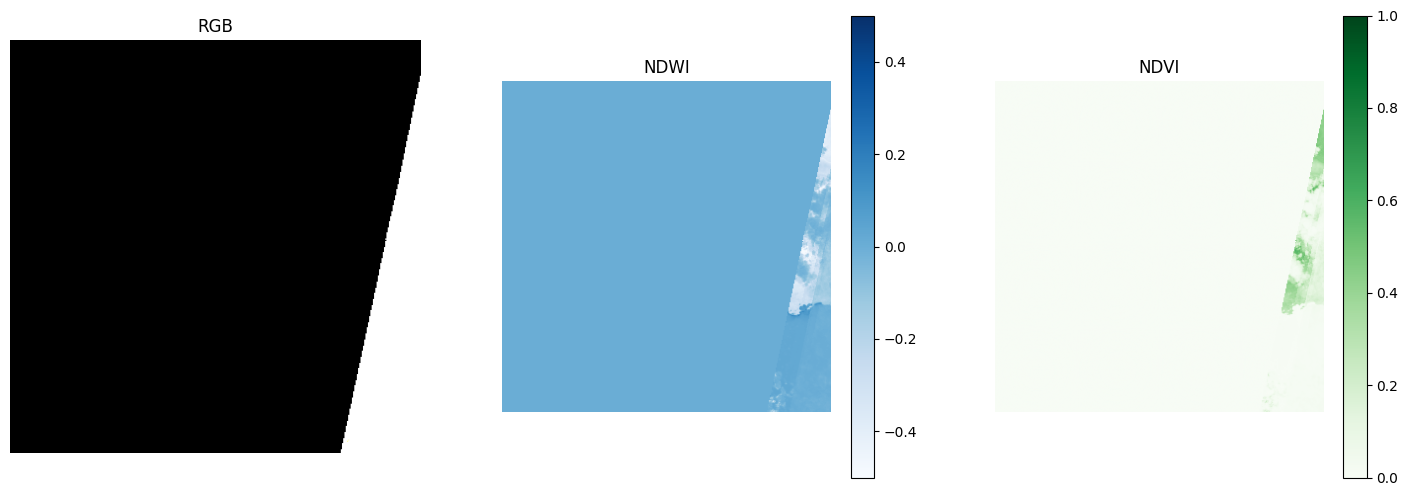

In [16]:
import ee
import geemap
import matplotlib.pyplot as plt

ee.Initialize(project='myproject-491120')

roi = ee.Geometry.Point([-90.5, -0.7]).buffer(20000)

# 👇 MENOS DATOS
collection = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
              .filterBounds(roi)
              .filterDate('2022-01-01', '2023-12-31')
              .limit(20))

# 👇 MÁS LIVIANO
image = collection.mean()

# Índices
ndwi = image.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
rgb = image.select(['SR_B4', 'SR_B3', 'SR_B2'])

# 👇 BAJA RESOLUCIÓN
scale = 120

rgb_np = geemap.ee_to_numpy(rgb, region=roi, scale=scale)
ndwi_np = geemap.ee_to_numpy(ndwi, region=roi, scale=scale)
ndvi_np = geemap.ee_to_numpy(ndvi, region=roi, scale=scale)

rgb_np = (rgb_np / 3000.0).clip(0, 1)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rgb_np)
axes[0].set_title("RGB")
axes[0].axis('off')

im1 = axes[1].imshow(ndwi_np, cmap='Blues', vmin=-0.5, vmax=0.5)
axes[1].set_title("NDWI")
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(ndvi_np, cmap='Greens', vmin=0, vmax=1)
axes[2].set_title("NDVI")
axes[2].axis('off')
fig.colorbar(im2, ax=axes[2])

plt.show()

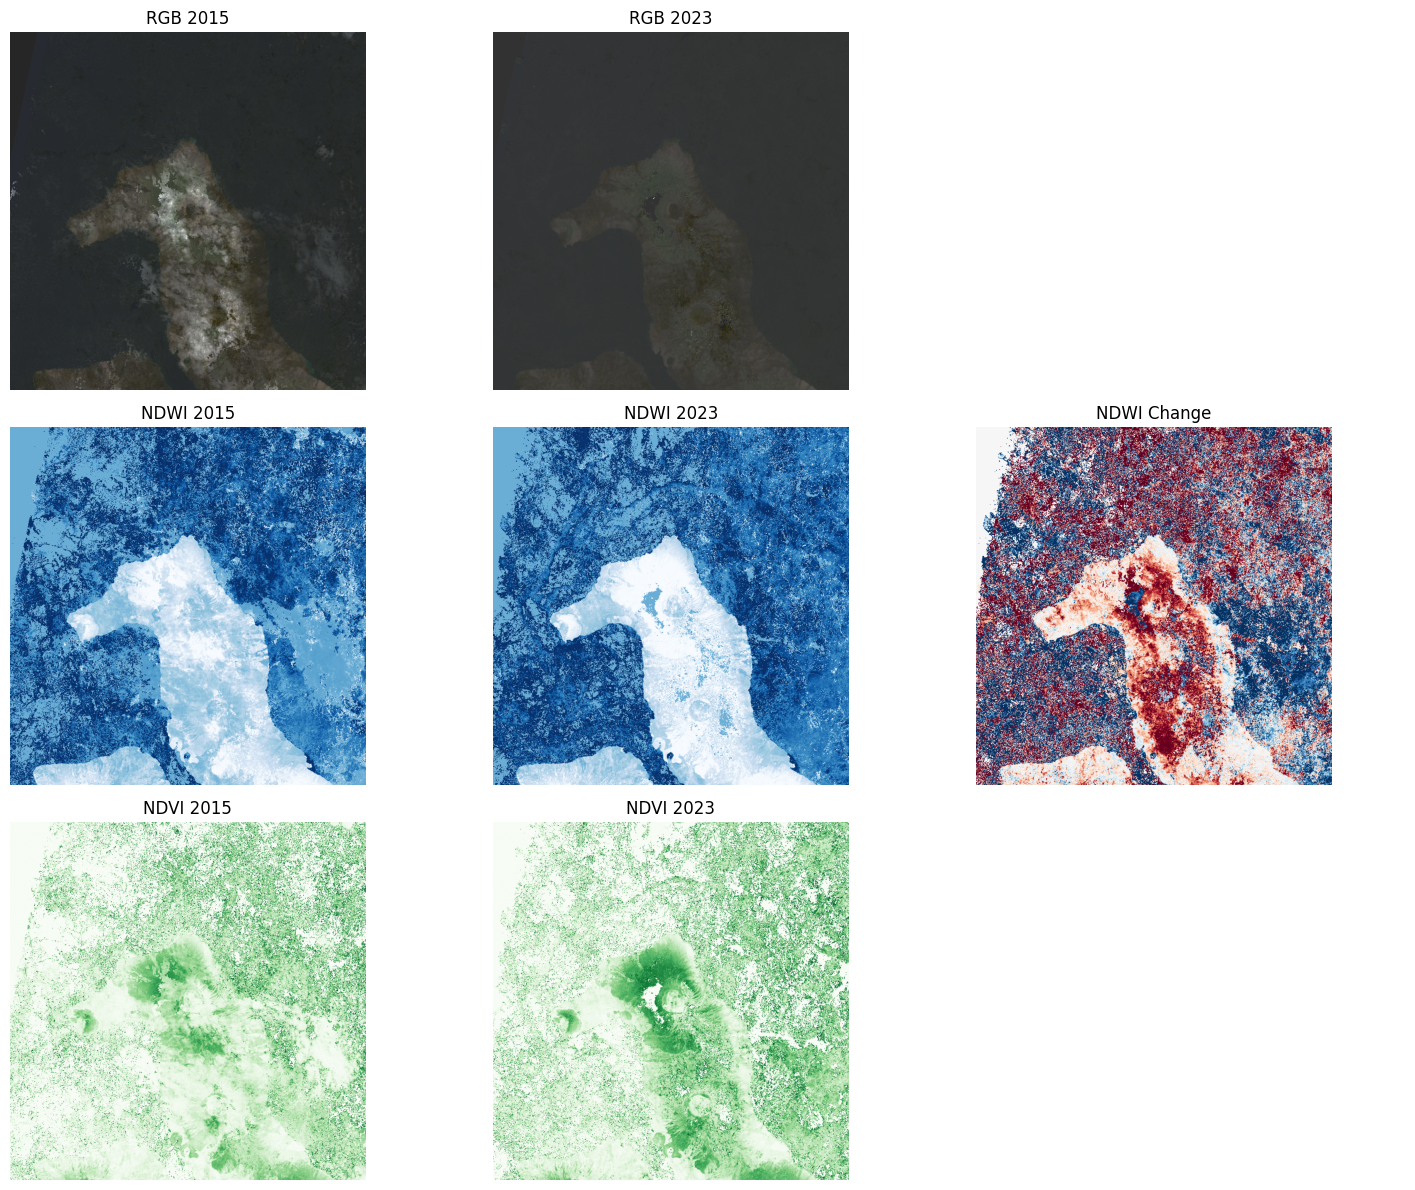

In [ ]:
import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np

ee.Initialize(project='myproject-491120')

# ROI
#roi = ee.Geometry.Point([-90.5, -0.7]).buffer(30000)
#roi = ee.Geometry.Point([-91.13, -0.83]).buffer(30000) # Volcán Sierra Negra
#roi = ee.Geometry.Point([-91.35, 0.02]).buffer(40000) # Volcán Wolf
roi = ee.Geometry.Point([-91.55, -0.37]).buffer(30000) # Volcán Fernandina

# =========================
# FUNCIÓN: limpiar nubes
# =========================
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    mask = qa.bitwiseAnd(1 << 3).eq(0)  # clouds
    return image.updateMask(mask)

# =========================
# FUNCIÓN: obtener imagen por año
# =========================
def get_image(year):
    col = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
           .filterBounds(roi)
           .filterDate(f'{year}-01-01', f'{year}-12-31')
           .map(mask_clouds)
           .limit(20))
    
    img = col.mean()

    # Escalar reflectancia (CLAVE para RGB)
    img = img.multiply(0.0000275).add(-0.2)

    rgb = img.select(['SR_B4', 'SR_B3', 'SR_B2'])
    ndwi = img.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
    ndvi = img.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')

    return rgb, ndwi, ndvi

# =========================
# Obtener años
# =========================
rgb15, ndwi15, ndvi15 = get_image(2015)
rgb23, ndwi23, ndvi23 = get_image(2023)

scale = 120

# =========================
# Convertir a numpy
# =========================
rgb15_np = geemap.ee_to_numpy(rgb15, region=roi, scale=scale)
rgb23_np = geemap.ee_to_numpy(rgb23, region=roi, scale=scale)

ndwi15_np = geemap.ee_to_numpy(ndwi15, region=roi, scale=scale)
ndwi23_np = geemap.ee_to_numpy(ndwi23, region=roi, scale=scale)

ndvi15_np = geemap.ee_to_numpy(ndvi15, region=roi, scale=scale)
ndvi23_np = geemap.ee_to_numpy(ndvi23, region=roi, scale=scale)

# =========================
# NORMALIZACIÓN RGB (FIX)
# =========================
def normalize_rgb(img):
    img = np.nan_to_num(img)
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)
    return img

rgb15_np = normalize_rgb(rgb15_np)
rgb23_np = normalize_rgb(rgb23_np)

# =========================
# DIFERENCIA NDWI (clave)
# =========================
ndwi_diff = ndwi23_np - ndwi15_np

# =========================
# SUBPLOTS
# =========================
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# ---- RGB ----
axes[0,0].imshow(rgb15_np)
axes[0,0].set_title("RGB 2015")
axes[0,0].axis('off')

axes[0,1].imshow(rgb23_np)
axes[0,1].set_title("RGB 2023")
axes[0,1].axis('off')

axes[0,2].axis('off')

# ---- NDWI ----
im1 = axes[1,0].imshow(ndwi15_np, cmap='Blues', vmin=-0.5, vmax=0.5)
axes[1,0].set_title("NDWI 2015")
axes[1,0].axis('off')

im2 = axes[1,1].imshow(ndwi23_np, cmap='Blues', vmin=-0.5, vmax=0.5)
axes[1,1].set_title("NDWI 2023")
axes[1,1].axis('off')

im3 = axes[1,2].imshow(ndwi_diff, cmap='RdBu', vmin=-0.3, vmax=0.3)
axes[1,2].set_title("NDWI Change")
axes[1,2].axis('off')

# ---- NDVI ----
im4 = axes[2,0].imshow(ndvi15_np, cmap='Greens', vmin=0, vmax=1)
axes[2,0].set_title("NDVI 2015")
axes[2,0].axis('off')

im5 = axes[2,1].imshow(ndvi23_np, cmap='Greens', vmin=0, vmax=1)
axes[2,1].set_title("NDVI 2023")
axes[2,1].axis('off')

axes[2,2].axis('off')

plt.tight_layout()
plt.show()

Exportar RGB

In [21]:
task_rgb = ee.batch.Export.image.toDrive(
    image=rgb23,
    description='RGB_2023_Galapagos',
    folder='EarthEngine',
    fileNamePrefix='rgb_2023',
    region=roi,
    scale=30,
    maxPixels=1e13
)

task_rgb.start()

Exportar NDWI

In [22]:
ndwi_diff_ee = ndwi23.subtract(ndwi15)

task_diff = ee.batch.Export.image.toDrive(
    image=ndwi_diff_ee,
    description='NDWI_CHANGE',
    folder='EarthEngine',
    fileNamePrefix='ndwi_change',
    region=roi,
    scale=30,
    maxPixels=1e13
)

task_diff.start()

In [26]:
url = ndwi23.getDownloadURL({
    'region': roi,
    'scale': 60,
    'format': 'GEO_TIFF'
})

print(url)

https://earthengine.googleapis.com/v1/projects/myproject-491120/thumbnails/50f5910fe661baac139afa24b35c0fd0-08accb4ca9d3aa0ef7637225e50c2e45:getPixels


In [27]:
import requests

r = requests.get(url)

with open('ndwi_2023.tif', 'wb') as f:
    f.write(r.content)